In [1]:
import csv
import sys
import networkx as nx
import matplotlib.pyplot as plt

import distanceclosure as dc
from distanceclosure.dijkstra import single_source_dijkstra_path_length

In [2]:
csv_file_path = 'fake_edges_no_receptors.csv'
original_ultrametric = '../../confidence_rank_ultrametric.csv'

output_csv_path = 'fake_edges_ultrametric_no_receptors.csv'
annotated_csv_path = 'fake_edges_annotated_no_receptors.csv'

source_col = 'Regulator'
target_col = 'Target'
weight_col = 'Confidence Rank'

MANUAL_FIXES = [('FOXP3', 'TGFB')]

In [3]:
edgelist = {}

with open(csv_file_path, mode='r', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    for row in reader:
        # Create the tuple key using the source and target columns
        edge = (row[source_col], row[target_col])
        
        # Convert the weight to an integer (or float if needed)
        weight = int(row[weight_col])
        
        # Add to the dictionary
        edgelist[edge] = weight

print(edgelist)
print(len(edgelist))

{('APC', 'CD28'): 1, ('APC', 'TCR'): 1, ('BCL6', 'GATA3'): 1, ('BCL6', 'IFNG'): 1, ('BCL6', 'IFNG_2'): 1, ('BCL6', 'IL21'): 1, ('BCL6', 'TBET'): 1, ('BCL6', 'TBET_2'): 1, ('CD28', 'NFAT'): 1, ('CD4', 'THPOK'): 2, ('CD8', 'RUNX3'): 2, ('CMAF', 'IL10'): 1, ('CMAF', 'IL21'): 1, ('CMAF', 'IL22'): 1, ('CMAF', 'IL4'): 1, ('DLL1', 'NOTCH1'): 1, ('EOMES', 'GZMB'): 1, ('EOMES', 'IFNG'): 1, ('EOMES', 'IFNG_2'): 1, ('EOMES', 'PRF1'): 1, ('FOXP3', 'GATA3'): 1, ('FOXP3', 'IL2'): 1, ('FOXP3', 'IL2RA'): 1, ('FOXP3', 'IL35'): 2, ('FOXP3', 'NFAT'): 1, ('FOXP3', 'NFKB'): 1, ('FOXP3', 'RORGT'): 1, ('FOXP3', 'TGFB'): 3, ('GATA3', 'GATA3'): 1, ('GATA3', 'IFNG'): 1, ('GATA3', 'IFNG_2'): 1, ('GATA3', 'IL13'): 1, ('GATA3', 'IL25'): 4, ('GATA3', 'IL3'): 1, ('GATA3', 'IL4'): 1, ('GATA3', 'IL5'): 1, ('GATA3', 'RORGT'): 1, ('GATA3', 'ST2'): 1, ('GATA3', 'STAT4'): 1, ('GATA3', 'TBET'): 1, ('GATA3', 'TBET_2'): 1, ('GATA3', 'THPOK'): 1, ('IFNAR', 'STAT1'): 1, ('IFNAR', 'STAT1_2'): 1, ('IFNA_e', 'IFNAR'): 1, ('IFNBR'

In [4]:
# Instanciate a (weighted) graph
G = nx.DiGraph()
weighted_edges = [(u, v, w) for (u, v), w in edgelist.items()]

G.add_weighted_edges_from(weighted_edges, weight='distance')

print(f"Nodes: {G.nodes()}")
print(f"Edges: {G.edges(data=True)}")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Nodes: ['APC', 'CD28', 'TCR', 'BCL6', 'GATA3', 'IFNG', 'IFNG_2', 'IL21', 'TBET', 'TBET_2', 'NFAT', 'CD4', 'THPOK', 'CD8', 'RUNX3', 'CMAF', 'IL10', 'IL22', 'IL4', 'DLL1', 'NOTCH1', 'EOMES', 'GZMB', 'PRF1', 'FOXP3', 'IL2', 'IL2RA', 'IL35', 'NFKB', 'RORGT', 'TGFB', 'IL13', 'IL25', 'IL3', 'IL5', 'ST2', 'STAT4', 'IFNAR', 'STAT1', 'STAT1_2', 'IFNA_e', 'IFNBR', 'IFNB_e', 'IFNGR', 'IFNGR_2', 'JAK1', 'IFNG_e', 'IKB', 'IL10R', 'STAT3', 'IL10_e', 'IL12R', 'IL12RB1_2', 'IL12RB2', 'IL12_e', 'IL15R', 'STAT5', 'IL15_e', 'IL18R', 'IRAK', 'IL18_e', 'IL1R', 'IL1R1', 'IL1_e', 'IL2R', 'IL2R_2', 'IL21R', 'IL21_e', 'IL23', 'IL23R', 'IL23_e', 'IL25R', 'IL25_e', 'IL27R', 'IL27_e', 'IL29R', 'IL29_e', 'STAT5_2', 'IL2_e', 'IL33R', 'IL9', 'IL33_e', 'IL36R', 'IL36_e', 'IL4R', 'IL4R_2', 'STAT6', 'IL4RA_2', 'IL4_e', 'IL6', 'IL6R', 'IL6_e', 'IL7R', 'IL7_e', 'IRF1', 'JAK3', 'IL17', 'IL31', 'PU1', 'SMAD2', 'SMAD3', 'SOCS1', 'proliferation', 'IL24', 'TGFBR', 'TGFB_e']
Edges: [('APC', 'CD28', {'distance': 1}), ('APC', 'T

In [5]:
B = dc.ultrametric_backbone(G, weight='distance', self_loops=False)

In [6]:
def print_report(graph):
    print(f"Number of nodes: {graph.number_of_nodes()}")
    print(f"Number of edges: {graph.number_of_edges()}")
    print(f"Number of self-loops: {len([e for e in graph.edges() if e[0] == e[1]])}")
    max_in_degree = 0
    max_in_degree_node = None
    log2_number_of_possible_BN = 1
    for node in graph.nodes():
        log2_number_of_possible_BN += 2**graph.in_degree(node)

        if graph.in_degree(node) > max_in_degree:
            max_in_degree = graph.in_degree(node)
            max_in_degree_node = node
    print("node with highest in-degree: ", max_in_degree_node, " with in-degree: ", max_in_degree)
    print("number of possible Boolean Networks: 2^", log2_number_of_possible_BN)

In [7]:
print_report(G)
print()
print_report(B)

Number of nodes: 106
Number of edges: 7645
Number of self-loops: 72
node with highest in-degree:  BCL6  with in-degree:  106
number of possible Boolean Networks: 2^ 5841333965851681082096808370372658

Number of nodes: 106
Number of edges: 996
Number of self-loops: 0
node with highest in-degree:  IFNG_2  with in-degree:  24
number of possible Boolean Networks: 2^ 29997106


In [8]:
target_nodes = [
    n for n in set(list(G.nodes()) + list(B.nodes()))
    if G.has_edge(n, n) or B.has_edge(n, n)
]

print(f"{len(target_nodes)} target nodes:", target_nodes)


72 target nodes: ['NFAT', 'IL4R_2', 'IL23R', 'IL25', 'SOCS1', 'IL24', 'STAT3', 'FOXP3', 'STAT5', 'THPOK', 'proliferation', 'IL22', 'IFNGR_2', 'IL2', 'IL4RA_2', 'RORGT', 'IL1R', 'PU1', 'TGFBR', 'TGFB', 'IL35', 'IL5', 'STAT1_2', 'IL6R', 'IL2R', 'STAT5_2', 'IRF1', 'IRAK', 'IFNGR', 'IFNG', 'PRF1', 'IL12R', 'IL12RB1_2', 'RUNX3', 'IL2R_2', 'IL10R', 'ST2', 'IL1R1', 'NFKB', 'IL18R', 'IL10', 'IL25R', 'STAT4', 'IL31', 'CMAF', 'SMAD3', 'TBET', 'STAT1', 'SMAD2', 'STAT6', 'CD4', 'JAK1', 'IL4', 'IL23', 'CD8', 'IL17', 'IL9', 'GATA3', 'IL12RB2', 'IL2RA', 'IL4R', 'EOMES', 'IL21', 'GZMB', 'IL33R', 'BCL6', 'IFNG_2', 'IL6', 'IL3', 'TBET_2', 'IL13', 'IL21R']


In [9]:
# --- Helper to process bottleneck cycles per graph ---
def get_bottleneck_cycles(graph, target_nodes):
    # Storage format: { target_node: { neighbor: (path_tuple, max_weight) } }
    results = {}
    
    for node in target_nodes:
        if node not in graph:
            continue
        results[node] = {}
        
        # 1. Capture standalone self-loops directly
        if graph.has_edge(node, node):
            results[node][node] = ((node, node), graph[node][node].get('distance'))
            
        # 2. Use your Dijkstra function to find the minimax return path from successors
        for neighbor in graph.successors(node):
            if neighbor == node:
                continue
                
            paths = {neighbor: [neighbor]}
            weight_fn = lambda v, u, e: e.get('distance')
            
            try:
                # Find the path that minimizes the maximum edge weight back to 'node'
                dist = single_source_dijkstra_path_length(
                    graph, 
                    source=neighbor, 
                    weight_function=weight_fn, 
                    paths=paths, 
                    disjunction=max
                )
                
                # If the target node was reached, a valid optimal bottleneck cycle exists
                if node in dist:
                    path_back = paths[node]
                    full_cycle = [node] + path_back
                    
                    # Total bottleneck is the max of the exit edge and the path back
                    exit_edge_w = graph[node][neighbor].get('distance')
                    cycle_max_w = max(exit_edge_w, dist[node])
                    
                    results[node][neighbor] = (tuple(full_cycle), cycle_max_w)
            except (nx.NodeNotFound, ValueError):
                continue
                
    return results

In [10]:
# Storage format: { target_node: { neighbor: (path_tuple, max_weight) } }
cycles_G = get_bottleneck_cycles(G, target_nodes)
cycles_B = get_bottleneck_cycles(B, target_nodes)

In [11]:
def check_cycles(cycles_G, cycles_B):
    errors = []

    for node in set(cycles_G) | set(cycles_B):
        g_routes = cycles_G.get(node, {})
        b_routes = cycles_B.get(node, {})

        # 1. Every cycle in B must also exist in G with the same weight
        for neighbor, (b_path, b_weight) in b_routes.items():
            g_route = g_routes.get(neighbor)

            if g_route is None:
                errors.append(
                    f"Node '{node}': cycle via '{neighbor}' "
                    f"exists in B but is missing in G."
                )
                continue

            g_path, g_weight = g_route

            if g_weight != b_weight:
                errors.append(
                    f"Node '{node}': cycle via '{neighbor}' has "
                    f"different weights: G={g_weight}, B={b_weight}."
                )

        # 2. Global minimum cycle weight must agree
        if g_routes and b_routes:
            min_weight_G = min(w for path, w in g_routes.values())
            min_weight_B = min(w for path, w in b_routes.values())

            if min_weight_G != min_weight_B:
                errors.append(
                    f"Node '{node}': minimum cycle weight differs: "
                    f"G={min_weight_G}, B={min_weight_B}."
                )

        elif g_routes and not b_routes:
            errors.append(
                f"Node '{node}': G has cycles but B has none."
            )

    return errors

In [12]:
errors = check_cycles(cycles_G, cycles_B)

if errors:
    print("Cycle check failed:")
    for error in errors:
        print(" -", error)
else:
    print("Cycle check passed.")

Cycle check passed.


In [13]:
def find_self_edges_to_restore(G, B, cycles_G):
    self_edges_to_restore = []

    for node in G.nodes:
        if not G.has_edge(node, node):
            continue

        if B.has_edge(node, node):
            continue

        g_routes = cycles_G.get(node, {})
        if not g_routes:
            continue

        min_weight_G = min(weight for path, weight in g_routes.values())
        self_weight_G = G[node][node].get("distance")

        if self_weight_G == min_weight_G:
            self_edges_to_restore.append(
                (node, node, G[node][node])
            )
            print(f"Found self-edge to restore: {node}, weight: {self_weight_G}")

    return self_edges_to_restore

In [14]:
self_edges_to_restore = find_self_edges_to_restore(
    G, B, cycles_G
)

B2 = B.copy()
B2.add_edges_from(self_edges_to_restore)

Found self-edge to restore: GATA3, weight: 1
Found self-edge to restore: THPOK, weight: 1
Found self-edge to restore: IL22, weight: 6
Found self-edge to restore: GZMB, weight: 6
Found self-edge to restore: PRF1, weight: 6
Found self-edge to restore: IL35, weight: 6
Found self-edge to restore: RORGT, weight: 1
Found self-edge to restore: IL13, weight: 6
Found self-edge to restore: IL3, weight: 6
Found self-edge to restore: IL5, weight: 6
Found self-edge to restore: STAT1, weight: 1
Found self-edge to restore: IL17, weight: 6
Found self-edge to restore: IL31, weight: 6
Found self-edge to restore: proliferation, weight: 4
Found self-edge to restore: IL24, weight: 6


In [15]:
cycles_B2 = get_bottleneck_cycles(B2, target_nodes)

In [16]:
errors = check_cycles(cycles_G, cycles_B2)

if errors:
    print("Cycle check failed:")
    for error in errors:
        print(" -", error)
else:
    print("Cycle check passed.")

Cycle check passed.


In [17]:
self_edges_to_restore = find_self_edges_to_restore(
    G, B2, cycles_G
)

if self_edges_to_restore:
    print(f"Found {len(self_edges_to_restore)} self-edges to restore.")
else:
    print("No self-edges to restore.")

No self-edges to restore.


In [18]:
print_report(G)
print()
print_report(B2)

Number of nodes: 106
Number of edges: 7645
Number of self-loops: 72
node with highest in-degree:  BCL6  with in-degree:  106
number of possible Boolean Networks: 2^ 5841333965851681082096808370372658

Number of nodes: 106
Number of edges: 1011
Number of self-loops: 15
node with highest in-degree:  IFNG_2  with in-degree:  24
number of possible Boolean Networks: 2^ 32342066


In [19]:
print("\n--- PHASE 3: MANUALLY RESTORING EDGES TO B ---")
B3 = B2.copy()
if MANUAL_FIXES:
    print(f"Adding {len(MANUAL_FIXES)} edges back into Graph B...")

    edges_to_add = []
    for edge in MANUAL_FIXES:
        u, v = edge
        edges_to_add.append((u, v, G[u][v]))

    B3.add_edges_from(edges_to_add)
    
    # Recalculate bottleneck paths for B now that it has been altered
    cycles_B_updated = get_bottleneck_cycles(B3, target_nodes)
else:
    print("No target nodes triggered the condition. Graph B remains unchanged.")


--- PHASE 3: MANUALLY RESTORING EDGES TO B ---
Adding 1 edges back into Graph B...


In [20]:
print_report(G)
print()
print_report(B3)

Number of nodes: 106
Number of edges: 7645
Number of self-loops: 72
node with highest in-degree:  BCL6  with in-degree:  106
number of possible Boolean Networks: 2^ 5841333965851681082096808370372658

Number of nodes: 106
Number of edges: 1012
Number of self-loops: 15
node with highest in-degree:  IFNG_2  with in-degree:  24
number of possible Boolean Networks: 2^ 32346162


In [21]:
# 2. Map Graph B edges into a dictionary for instant lookups
edges_B2_dict = {}
for u, v, data in B3.edges(data=True):
    # Checks both common attribute names ('weight' or 'distance')
    weight_val = data.get('weight') or data.get('distance')
    edges_B2_dict[(str(u), str(v))] = weight_val

# 3. Stream through the input CSV and write to both outputs simultaneously
matching_rows_count = 0
total_rows_count = 0
line_number = 1

with open(csv_file_path, mode='r', encoding='utf-8') as infile, \
     open(output_csv_path, mode='w', encoding='utf-8', newline='') as filtered_file, \
     open(annotated_csv_path, mode='w', encoding='utf-8', newline='') as annotated_file:
    
    reader = csv.DictReader(infile)
    
    # Setup Output 1: Filtered file (identical columns to input)
    filtered_writer = csv.DictWriter(filtered_file, fieldnames=reader.fieldnames)
    filtered_writer.writeheader()
    
    # Setup Output 2: Annotated file (input columns + the new extra status column)
    annotated_fieldnames = list(reader.fieldnames) + ['is_kept']
    annotated_writer = csv.DictWriter(annotated_file, fieldnames=annotated_fieldnames)
    annotated_writer.writeheader()
    
    for row in reader:
        line_number += 1
        total_rows_count += 1
        
        row_src = str(row[source_col])
        row_tgt = str(row[target_col])
        
        try:
            # Change int() to float() if your weights contain decimals
            row_weight = int(row[weight_col]) 
            is_valid_weight = True
        except (ValueError, TypeError):
            print(f"⚠️ Warning: Non-numeric weight skipped on line {line_number}.", file=sys.stderr)
            is_valid_weight = False
            
        edge_key = (row_src, row_tgt)
        is_kept = False
        
        # Evaluate if the edge matches Graph B criteria
        if is_valid_weight and (edge_key in edges_B2_dict):
            graph_weight = edges_B2_dict[edge_key]
            
            if row_weight == graph_weight:
                is_kept = True
            else:
                print(f"⚠️ Weight Mismatch Warning [Line {line_number}]: Connection ({row_src} -> {row_tgt}) "
                      f"found in B, but weights disagree! (CSV: {row_weight} vs Graph B: {graph_weight})")
        
        # --- Handle Output 1 (Filtered) ---
        if is_kept:
            filtered_writer.writerow(row)
            matching_rows_count += 1
            
        # --- Handle Output 2 (Annotated) ---
        # Make a copy of the row so we don't accidentally modify the row dat2 used by other operations
        annotated_row = dict(row)
        annotated_row['is_kept'] = "KEPT" if is_kept else "TAKEN_OUT"
        annotated_writer.writerow(annotated_row)

print("\n🎉 Done! Processing completed successfully.")
print(f"   * Total original rows processed: {total_rows_count}")
print(f"   * Filtered output created: '{output_csv_path}' ({matching_rows_count} rows)")
print(f"   * Annotated output created: '{annotated_csv_path}' ({total_rows_count} rows)")



🎉 Done! Processing completed successfully.
   * Total original rows processed: 7645
   * Filtered output created: 'fake_edges_ultrametric_no_receptors.csv' (1012 rows)
   * Annotated output created: 'fake_edges_annotated_no_receptors.csv' (7645 rows)


In [22]:
def plot_node_degree_reduction_profile_v5(
    U, G, B,
    selected_nodes=None,
    label_U="Original Backbone",
):
    """
    Decomposes G into:

        U + survived fake edges + reduced fake edges

    Selected nodes are treated as a separate category for survived
    fake edges.

    Node ordering:
        1. Source nodes with zero U in-degree, alphabetical
        2. selected_nodes, alphabetical
        3. remaining nodes, ordered by U in-degree
    """

    if selected_nodes is None:
        selected_nodes = set()
    else:
        selected_nodes = set(selected_nodes)

    # ------------------------------------------------------------
    # 1. Build node profiles
    # ------------------------------------------------------------

    node_profiles = []

    for node in G.nodes():
        deg_U = U.in_degree(node) if node in U else 0
        deg_G = G.in_degree(node)
        deg_B = B.in_degree(node) if node in B else 0

        survived_fake = deg_B - deg_U
        reduced_fake = deg_G - deg_B

        node_profiles.append({
            "node": str(node),
            "original": deg_U,
            "survived": survived_fake,
            "reduced": reduced_fake,
            "total": deg_G,
            "selected": node in selected_nodes,
        })

    # ------------------------------------------------------------
    # 2. Order nodes
    # ------------------------------------------------------------

    source_nodes = [
        x for x in node_profiles
        if x["original"] == 0 and not x["selected"]
    ]

    receptor_nodes = [
        x for x in node_profiles
        if x["selected"]
    ]

    remaining_nodes = [
        x for x in node_profiles
        if x["original"] != 0 and not x["selected"]
    ]

    source_nodes.sort(key=lambda x: x["node"])
    receptor_nodes.sort(key=lambda x: x["node"])
    remaining_nodes.sort(
        key=lambda x: (x["original"], x["node"])
    )

    node_profiles = source_nodes + receptor_nodes + remaining_nodes

    # ------------------------------------------------------------
    # 3. Extract plotting arrays
    # ------------------------------------------------------------

    x = range(len(node_profiles))

    original = [p["original"] for p in node_profiles]

    survived_regular = [
        p["survived"] if not p["selected"] else 0
        for p in node_profiles
    ]

    reduced = [p["reduced"] for p in node_profiles]

    labels = [p["node"] for p in node_profiles]

    # ------------------------------------------------------------
    # 4. Global percentages
    # ------------------------------------------------------------

    total_original = sum(original)
    total_survived = sum(p["survived"] for p in node_profiles)
    total_reduced = sum(reduced)

    total_fake = total_survived + total_reduced

    if total_fake > 0:
        pct_regular = 100 * total_survived / total_fake
        pct_reduced = 100 * total_reduced / total_fake
    else:
        pct_regular = pct_reduced = 0

    # ------------------------------------------------------------
    # 5. Plot
    # ------------------------------------------------------------

    plt.figure(figsize=(16, 6))

    # Original backbone
    plt.bar(
        x,
        original,
        color="royalblue",
        edgecolor="black",
        alpha=0.85,
        linewidth=0.5,
        label=f"{label_U} ({total_original})"
    )

    # Survived fake edges on ordinary nodes
    plt.bar(
        x,
        survived_regular,
        bottom=original,
        color="darkorange",
        edgecolor="black",
        alpha=0.85,
        linewidth=0.5,
        label=f"Survived Fake Edges ({total_survived}, {pct_regular:.1f}%)"
    )

    # Reduced fake edges
    reduced_bottom = [
        u + s
        for u, s in zip(
            original,
            survived_regular,
        )
    ]

    plt.bar(
        x,
        reduced,
        bottom=reduced_bottom,
        color="crimson",
        edgecolor="black",
        alpha=0.85,
        linewidth=0.5,
        label=f"Reduced Fake Edges ({total_reduced}, {pct_reduced:.1f}%)"
    )

    # ------------------------------------------------------------
    # 6. Formatting
    # ------------------------------------------------------------

    plt.title(
        "Node-by-Node In-Degree Reduction Profile",
        fontsize=14,
        weight="bold"
    )

    plt.xlabel(
        "Individual Nodes",
        fontsize=12
    )

    plt.ylabel(
        "In-Degree Count",
        fontsize=12
    )

    plt.xticks(
        list(x),
        labels,
        rotation=90,
        ha="center",
        fontsize=8
    )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.5
    )

    plt.legend(
        fontsize=10,
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

In [23]:
edgelist = {}

with open(original_ultrametric, mode='r', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    for row in reader:
        # Create the tuple key using the source and target columns
        edge = (row[source_col], row[target_col])
        
        # Convert the weight to an integer (or float if needed)
        weight = int(row[weight_col])
        
        # Add to the dictionary
        edgelist[edge] = weight

print(edgelist)
print(len(edgelist))

{('APC', 'CD28'): 1, ('APC', 'TCR'): 1, ('BCL6', 'GATA3'): 1, ('BCL6', 'IFNG'): 1, ('BCL6', 'IFNG_2'): 1, ('BCL6', 'IL21'): 1, ('BCL6', 'TBET'): 1, ('BCL6', 'TBET_2'): 1, ('CD28', 'NFAT'): 1, ('CD4', 'THPOK'): 2, ('CD8', 'RUNX3'): 2, ('CMAF', 'IL10'): 1, ('CMAF', 'IL21'): 1, ('CMAF', 'IL22'): 1, ('CMAF', 'IL4'): 1, ('DLL1', 'NOTCH1'): 1, ('EOMES', 'GZMB'): 1, ('EOMES', 'IFNG'): 1, ('EOMES', 'IFNG_2'): 1, ('EOMES', 'PRF1'): 1, ('FOXP3', 'GATA3'): 1, ('FOXP3', 'IL2'): 1, ('FOXP3', 'IL2RA'): 1, ('FOXP3', 'IL35'): 2, ('FOXP3', 'NFAT'): 1, ('FOXP3', 'NFKB'): 1, ('FOXP3', 'RORGT'): 1, ('FOXP3', 'TGFB'): 3, ('GATA3', 'GATA3'): 1, ('GATA3', 'IFNG'): 1, ('GATA3', 'IFNG_2'): 1, ('GATA3', 'IL13'): 1, ('GATA3', 'IL25'): 4, ('GATA3', 'IL3'): 1, ('GATA3', 'IL4'): 1, ('GATA3', 'IL5'): 1, ('GATA3', 'RORGT'): 1, ('GATA3', 'ST2'): 1, ('GATA3', 'STAT4'): 1, ('GATA3', 'TBET'): 1, ('GATA3', 'TBET_2'): 1, ('GATA3', 'THPOK'): 1, ('IFNAR', 'STAT1'): 1, ('IFNAR', 'STAT1_2'): 1, ('IFNA_e', 'IFNAR'): 1, ('IFNBR'

In [24]:
# Instanciate a (weighted) graph
U = nx.DiGraph()
weighted_edges = [(u, v, w) for (u, v), w in edgelist.items()]

U.add_weighted_edges_from(weighted_edges, weight='distance')

print(f"Nodes: {U.nodes()}")
print(f"Edges: {U.edges(data=True)}")
print(f"Number of nodes: {U.number_of_nodes()}")
print(f"Number of edges: {U.number_of_edges()}")

Nodes: ['APC', 'CD28', 'TCR', 'BCL6', 'GATA3', 'IFNG', 'IFNG_2', 'IL21', 'TBET', 'TBET_2', 'NFAT', 'CD4', 'THPOK', 'CD8', 'RUNX3', 'CMAF', 'IL10', 'IL22', 'IL4', 'DLL1', 'NOTCH1', 'EOMES', 'GZMB', 'PRF1', 'FOXP3', 'IL2', 'IL2RA', 'IL35', 'NFKB', 'RORGT', 'TGFB', 'IL13', 'IL25', 'IL3', 'IL5', 'ST2', 'STAT4', 'IFNAR', 'STAT1', 'STAT1_2', 'IFNA_e', 'IFNBR', 'IFNB_e', 'IFNGR', 'IFNGR_2', 'JAK1', 'IFNG_e', 'IKB', 'IL10R', 'STAT3', 'IL10_e', 'IL12R', 'IL12RB1_2', 'IL12RB2', 'IL12_e', 'IL15R', 'STAT5', 'IL15_e', 'IL18R', 'IRAK', 'IL18_e', 'IL1R', 'IL1R1', 'IL1_e', 'IL2R', 'IL2R_2', 'IL21R', 'IL21_e', 'IL23', 'IL23R', 'IL23_e', 'IL25R', 'IL25_e', 'IL27R', 'IL27_e', 'IL29R', 'IL29_e', 'STAT5_2', 'IL2_e', 'IL33R', 'IL9', 'IL33_e', 'IL36R', 'IL36_e', 'IL4R', 'IL4R_2', 'STAT6', 'IL4RA_2', 'IL4_e', 'IL6', 'IL6R', 'IL6_e', 'IL7R', 'IL7_e', 'IRF1', 'JAK3', 'IL17', 'IL31', 'PU1', 'SMAD2', 'SMAD3', 'SOCS1', 'proliferation', 'IL24', 'TGFBR', 'TGFB_e']
Edges: [('APC', 'CD28', {'distance': 1}), ('APC', 'T

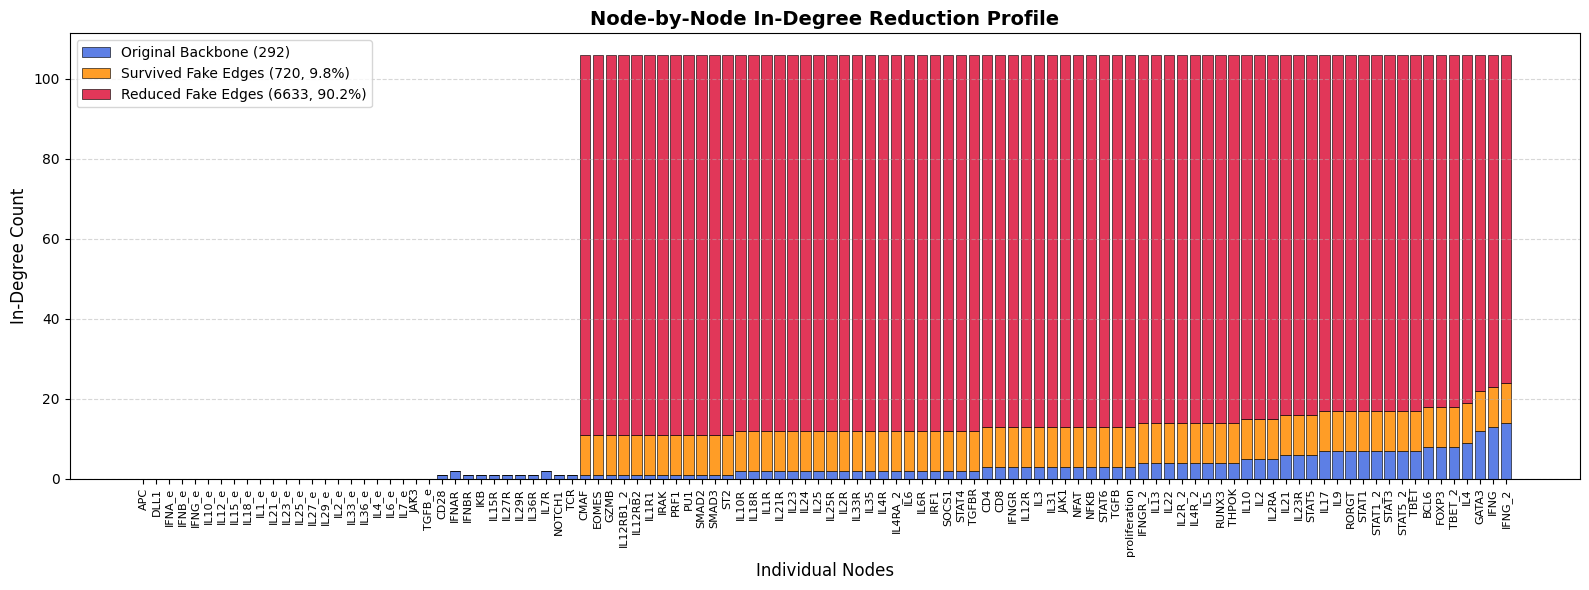

In [25]:
plot_node_degree_reduction_profile_v5(
    U,
    G,
    B3,
    selected_nodes=["IKB", "IL7R", "CD28", "TCR", "NOTCH1", "IFNAR", "IFNBR", "IL15R", "IL27R", "IL29R", "IL36R"]
)